# DenseNet121 Dual-Input Hyperparameter Optimization
### Thesis notebook — Stages 0-3

This notebook optimizes the dual-input DenseNet121 architecture (full mammogram + cropped lesion,
concatenated features, shared classifier) that was identified as the best-performing backbone in
prior architecture comparisons (~76% baseline validation accuracy).

**Stages included in this notebook:**
- Stage 0 — Baseline verification
- Stage 1 — Learning rate optimization
- Stage 2 — Weight decay optimization
- Stage 3 — LR scheduler optimization

Stages 4-6 (augmentation, class imbalance, optimizer choice) and the final combined training run
follow the same pattern established here and can be appended as additional sections once these
results are reviewed — this keeps the first pass fast to run and cheap to iterate on.

Only **one hyperparameter category is changed per stage**; every experiment starts from fresh
ImageNet weights (never from a previously trained checkpoint) so comparisons stay fair.


In [1]:
# --- Install / import dependencies ---
import os, time, json, random, warnings, gc
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128 | CUDA available: True


c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Load dataframes ---
# Expected columns: ["patient_id", "pathology", "image file path",
#                     "cropped image file path", "full image cached path",
#                     "cropped image cached path"]
train_df = pd.read_csv("../../dataframes/train_df_final.csv")
val_df   = pd.read_csv("../../dataframes/val_df_final.csv")
test_df  = pd.read_csv("../../dataframes/test_df_final.csv")

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))


train: 2599 val: 328 test: 326


In [3]:
# --- Global configuration ---
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_WORKERS = 4 if os.name != "nt" else 0

HEAD_WARMUP_EPOCHS = 5      # Phase 1: backbones frozen, head-only
MAX_EPOCHS = 40             # capped per-experiment budget (Phase 1 + Phase 2)
EARLY_STOPPING_PATIENCE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FULL_PATH_COL = "full image cached path"
CROP_PATH_COL = "cropped image cached path"
LABEL_COL = "pathology"
CLASS_NAMES = ["Benign", "Malignant"]

# Baseline config (matches the previous architecture-comparison run)
BASELINE = dict(
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
    scheduler="plateau",   # "plateau" | "cosine" | "onecycle"
)

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [4]:
# --- Label encoding, transforms, dataset ---
def encode_label(raw_label):
    try:
        return int(raw_label)
    except (ValueError, TypeError):
        pass
    text = str(raw_label).strip().upper()
    return 1 if "MALIGNANT" in text else 0


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class DualImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_image = Image.open(row[FULL_PATH_COL]).convert("RGB")
        cropped_image = Image.open(row[CROP_PATH_COL]).convert("RGB")
        full_image = self.transform(full_image)
        cropped_image = self.transform(cropped_image)
        label = torch.tensor(encode_label(row[LABEL_COL]), dtype=torch.long)
        return full_image, cropped_image, label


def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        DualImageDataset(train_df, train_transform), batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        DualImageDataset(val_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        DualImageDataset(test_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader


In [5]:
# --- DenseNet121 dual-input model ---
def build_densenet_backbone():
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    base = models.densenet121(weights=weights)
    feature_extractor = nn.Sequential(
        base.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)),
    )
    return feature_extractor, 1024


class DualInputDenseNet(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.full_extractor, feat_dim_full = build_densenet_backbone()
        self.crop_extractor, feat_dim_crop = build_densenet_backbone()
        combined_dim = feat_dim_full + feat_dim_crop
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image, cropped_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        combined = torch.cat([full_feat, crop_feat], dim=1)
        return self.classifier(combined)

    def set_backbones_trainable(self, trainable: bool):
        for extractor in (self.full_extractor, self.crop_extractor):
            for p in extractor.parameters():
                p.requires_grad = trainable
            extractor.train(trainable)


In [6]:
# --- Metrics + epoch runner ---
def compute_metrics(labels, preds, probs):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=False, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    with grad_context:
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=desc, leave=False):
            full_imgs = full_imgs.to(device, non_blocking=True)
            crop_imgs = crop_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, (all_labels, all_preds, all_probs)


In [7]:
# --- Generic single-experiment trainer (parameterized hyperparameters) ---
def build_scheduler(name, optimizer, steps_per_epoch=None, total_epochs=None):
    if name == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5), "epoch"
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1)), "epoch"
    if name == "onecycle":
        max_lrs = [g["lr"] for g in optimizer.param_groups]
        sched = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs, steps_per_epoch=steps_per_epoch, epochs=total_epochs,
        )
        return sched, "batch"
    raise ValueError(f"Unknown scheduler: {name}")


def train_experiment(exp_name, head_lr, backbone_lr, weight_decay, scheduler_name,
                      train_loader, val_loader, max_epochs=MAX_EPOCHS):
    """Trains one DualInputDenseNet from fresh ImageNet weights with the given
    hyperparameters. Returns (history_dict, best_checkpoint_dict)."""
    set_seed(SEED)
    print(f"\n{'='*80}\nExperiment: {exp_name}\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name}\n{'='*80}")

    model = DualInputDenseNet().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, backbones frozen ----
    model.set_backbones_trainable(False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr, weight_decay=weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m, _ = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                      desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)

    # ---- Phase 2: unfreeze backbones, discriminative LR ----
    model.set_backbones_trainable(True)
    optimizer = optim.AdamW([
        {"params": model.full_extractor.parameters(), "lr": backbone_lr},
        {"params": model.crop_extractor.parameters(), "lr": backbone_lr},
        {"params": model.classifier.parameters(), "lr": head_lr},
    ], weight_decay=weight_decay)

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        model.train()
        running_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
        for full_imgs, crop_imgs, labels in tqdm(train_loader, desc=f"{exp_name} e{global_epoch} [train]", leave=False):
            full_imgs = full_imgs.to(DEVICE, non_blocking=True)
            crop_imgs = crop_imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_mode == "batch":
                scheduler.step()
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
        tr_loss = running_loss / len(train_loader.dataset)
        tr_m = compute_metrics(all_labels, all_preds, all_probs)

        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    del model
    free_gpu()

    result_row = {
        "experiment": exp_name, "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


In [8]:
# --- Full evaluation (val or test set) for the best checkpoint of an experiment ---
def evaluate_checkpoint(ckpt_path, loader, tag=""):
    model = DualInputDenseNet().to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs, crop_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE)
            outputs = model(full_imgs, crop_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}


In [9]:
# --- Plotting helpers ---
def plot_curves(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["lr"])
    axes[2].set_title(f"{title_prefix} — Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log")

    plt.tight_layout(); plt.show()


def plot_confusion_and_curves(eval_result, title_prefix):
    labels, preds, probs = eval_result["labels"], eval_result["preds"], eval_result["probs"]
    cm = eval_result["confusion_matrix"]
    fpr, tpr, _ = roc_curve(labels, probs)
    prec, rec, _ = precision_recall_curve(labels, probs)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    im = axes[0].imshow(cm, cmap="Blues")
    axes[0].set_title(f"{title_prefix} — Confusion Matrix")
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center")

    axes[1].plot(fpr, tpr, label=f"AUC={eval_result['metrics']['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_title(f"{title_prefix} — ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

    axes[2].plot(rec, prec)
    axes[2].set_title(f"{title_prefix} — Precision-Recall Curve")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")

    plt.tight_layout(); plt.show()
    print(eval_result["report"])


## Stage 0 — Baseline Verification

Trains the current baseline configuration (matching the earlier architecture-comparison run) from
fresh ImageNet weights, and records the reference metrics/curves that every later stage will be
compared against.



Experiment: stage0_baseline
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


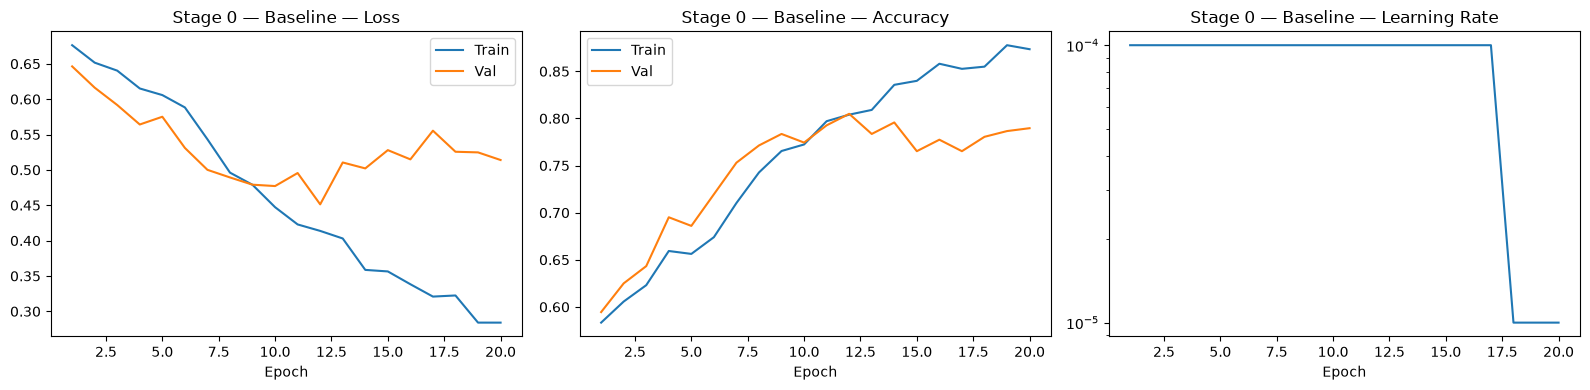

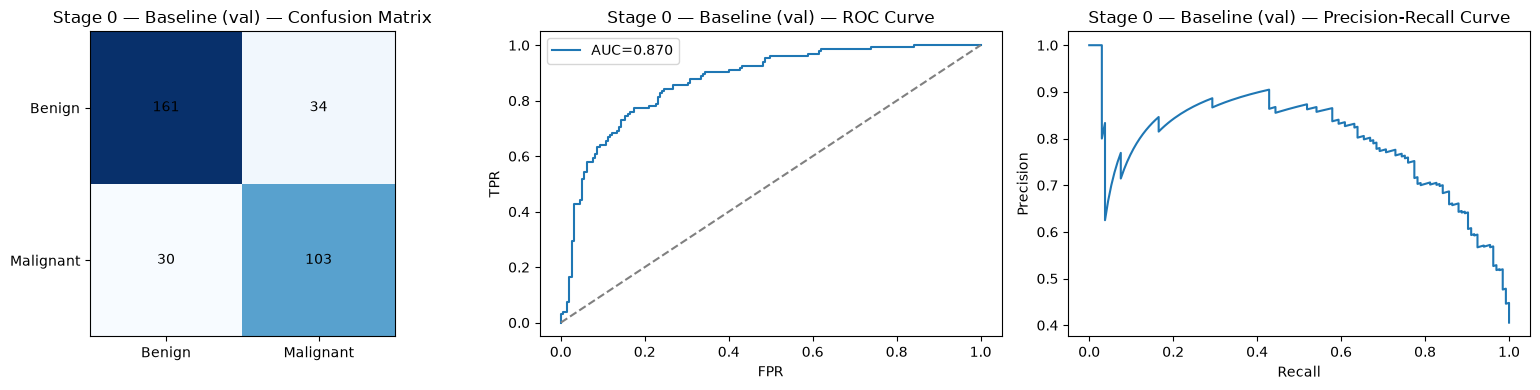

              precision    recall  f1-score   support

      Benign       0.84      0.83      0.83       195
   Malignant       0.75      0.77      0.76       133

    accuracy                           0.80       328
   macro avg       0.80      0.80      0.80       328
weighted avg       0.81      0.80      0.81       328



,experiment,head_lr,backbone_lr,weight_decay,scheduler,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,stage0_baseline,0.0001,0.00001,0.0001,plateau,12,20,0.451265,0.804878,1062.4,checkpoints\stage0_baseline.pth


In [10]:
train_loader, val_loader, test_loader = make_loaders()

stage0_history, stage0_ckpt, stage0_row = train_experiment(
    exp_name="stage0_baseline",
    head_lr=BASELINE["head_lr"], backbone_lr=BASELINE["backbone_lr"],
    weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
    train_loader=train_loader, val_loader=val_loader,
)

plot_curves(stage0_history, "Stage 0 — Baseline")
baseline_eval = evaluate_checkpoint(stage0_row["checkpoint_path"], val_loader, tag="stage0-val")
plot_confusion_and_curves(baseline_eval, "Stage 0 — Baseline (val)")

all_results = [stage0_row]
pd.DataFrame(all_results)


## Stage 1 — Learning Rate Optimization

Only the learning rate is varied (head LR and backbone LR scaled together, keeping the same 10x
discriminative ratio used in the baseline). Everything else — augmentation, optimizer, scheduler,
dataset, epoch budget, seed — is held identical across runs.



Experiment: stage1_lr_3e-05
head_lr=3e-05 backbone_lr=3e-06 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6787 acc 0.5718 | val_loss 0.6628 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6666 acc 0.5965 | val_loss 0.6457 acc 0.5976


  [warmup] epoch  3 | train_loss 0.6569 acc 0.6142 | val_loss 0.6370 acc 0.5945


  [warmup] epoch  4 | train_loss 0.6414 acc 0.6312 | val_loss 0.6155 acc 0.6250


...

  epoch 23 | train_loss 0.4109 acc 0.8079 | val_loss 0.4741 acc 0.7835 | lr(head) 3.00e-05


  epoch 24 | train_loss 0.4105 acc 0.7998 | val_loss 0.4859 acc 0.7713 | lr(head) 3.00e-05


  epoch 25 | train_loss 0.4049 acc 0.8194 | val_loss 0.4849 acc 0.7713 | lr(head) 3.00e-06


  epoch 26 | train_loss 0.3844 acc 0.8299 | val_loss 0.4827 acc 0.7774 | lr(head) 3.00e-06


  epoch 27 | train_loss 0.3731 acc 0.8237 | val_loss 0.4777 acc 0.7835 | lr(head) 3.00e-06
  Early stopping at epoch 27.


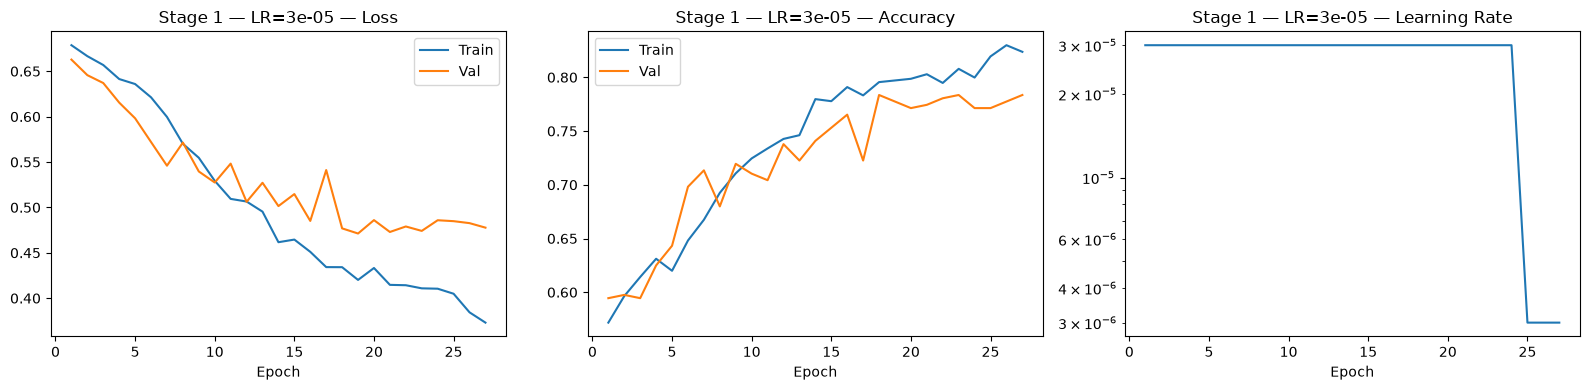


Experiment: stage1_lr_1e-04
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


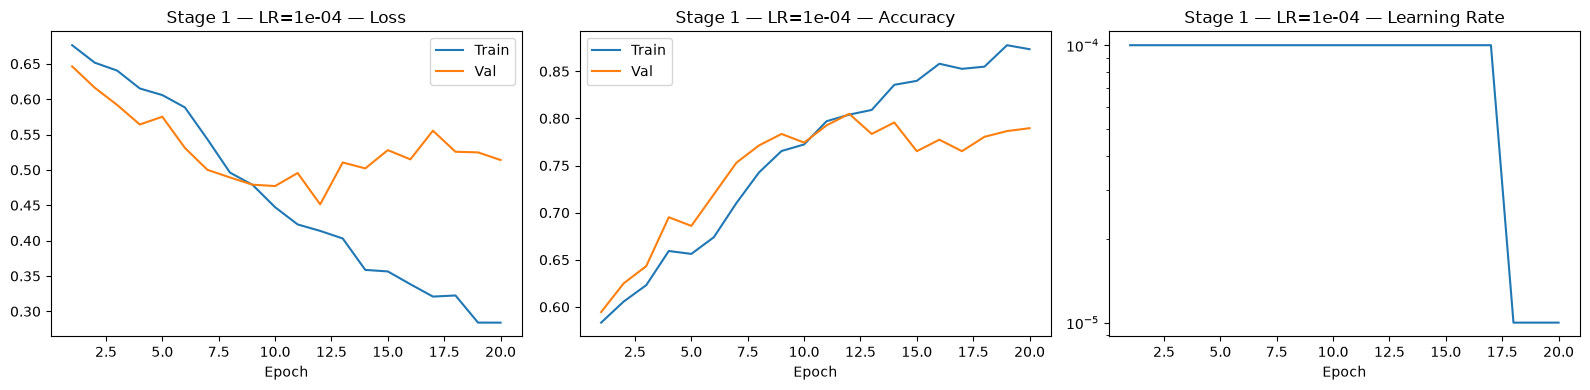


Experiment: stage1_lr_3e-04
head_lr=0.0003 backbone_lr=2.9999999999999997e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6851 acc 0.5683 | val_loss 0.6372 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6505 acc 0.6231 | val_loss 0.6275 acc 0.6067


  [warmup] epoch  3 | train_loss 0.6301 acc 0.6339 | val_loss 0.5763 acc 0.6799


  [warmup] epoch  4 | train_loss 0.6058 acc 0.6759 | val_loss 0.5579 acc 0.7012


...

  epoch 11 | train_loss 0.3761 acc 0.8299 | val_loss 0.5131 acc 0.7835 | lr(head) 3.00e-04


  epoch 12 | train_loss 0.3606 acc 0.8418 | val_loss 0.5200 acc 0.7500 | lr(head) 3.00e-04


  epoch 13 | train_loss 0.3243 acc 0.8603 | val_loss 0.5843 acc 0.7470 | lr(head) 3.00e-05


  epoch 14 | train_loss 0.2911 acc 0.8727 | val_loss 0.5523 acc 0.7744 | lr(head) 3.00e-05


  epoch 15 | train_loss 0.2640 acc 0.8985 | val_loss 0.5749 acc 0.7652 | lr(head) 3.00e-05
  Early stopping at epoch 15.


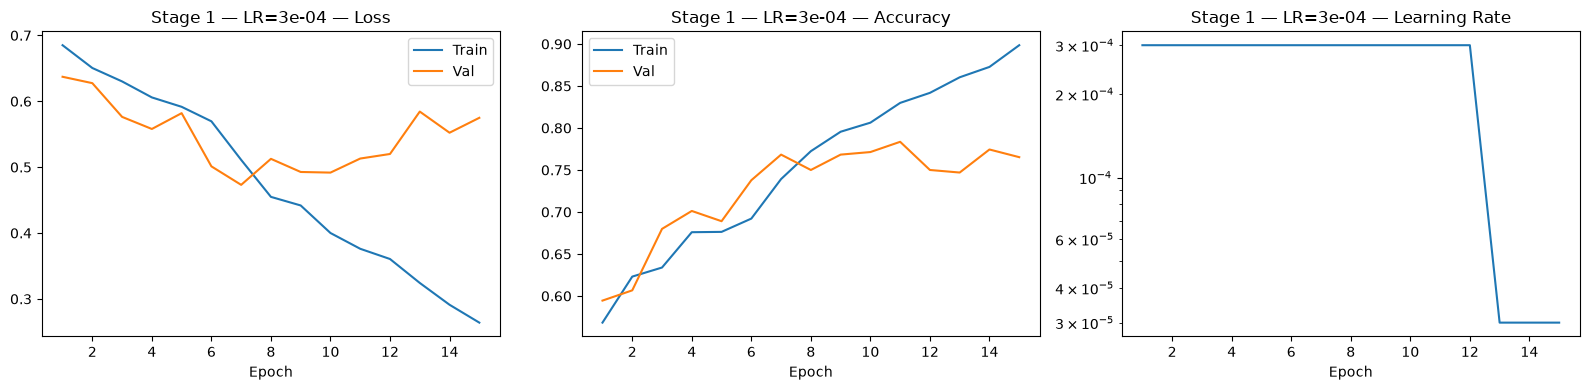


Experiment: stage1_lr_1e-03
head_lr=0.001 backbone_lr=0.0001 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.7110 acc 0.5652 | val_loss 0.6526 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6662 acc 0.5883 | val_loss 0.6287 acc 0.5945


  [warmup] epoch  3 | train_loss 0.6333 acc 0.6292 | val_loss 0.5591 acc 0.6951


  [warmup] epoch  4 | train_loss 0.6273 acc 0.6447 | val_loss 0.5852 acc 0.6768


...

  epoch 18 | train_loss 0.3319 acc 0.8592 | val_loss 0.7010 acc 0.7287 | lr(head) 1.00e-03


  epoch 19 | train_loss 0.3098 acc 0.8615 | val_loss 0.6419 acc 0.7134 | lr(head) 1.00e-03


  epoch 20 | train_loss 0.3084 acc 0.8746 | val_loss 0.6028 acc 0.7317 | lr(head) 1.00e-04


  epoch 21 | train_loss 0.2201 acc 0.9090 | val_loss 0.6311 acc 0.7378 | lr(head) 1.00e-04


  epoch 22 | train_loss 0.2062 acc 0.9159 | val_loss 0.7061 acc 0.7348 | lr(head) 1.00e-04
  Early stopping at epoch 22.


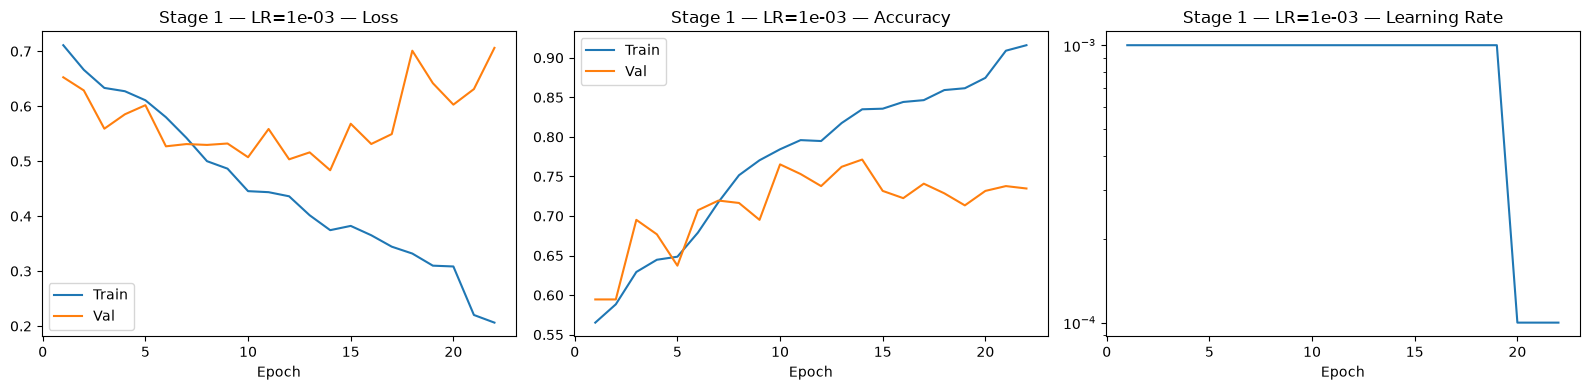

,experiment,head_lr,backbone_lr,weight_decay,scheduler,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,stage1_lr_3e-05,0.00003,0.000003,0.0001,plateau,19,27,0.471264,0.777439,1735.9,checkpoints\stage1_lr_3e-05.pth
1,stage1_lr_1e-04,0.00010,0.000010,0.0001,plateau,12,20,0.451265,0.804878,1288.4,checkpoints\stage1_lr_1e-04.pth
2,stage1_lr_3e-04,0.00030,0.000030,0.0001,plateau,7,15,0.473131,0.768293,838.0,checkpoints\stage1_lr_3e-04.pth
3,stage1_lr_1e-03,0.00100,0.000100,0.0001,plateau,14,22,0.483514,0.771341,1170.6,checkpoints\stage1_lr_1e-03.pth


In [11]:
# Log-spaced search grid around the baseline head_lr (1e-4)
LR_GRID = [3e-5, 1e-4, 3e-4, 1e-3]

stage1_results = []
stage1_histories = {}
for head_lr in LR_GRID:
    backbone_lr = head_lr / 10  # keep the 10x discriminative ratio fixed
    name = f"stage1_lr_{head_lr:.0e}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=head_lr, backbone_lr=backbone_lr,
        weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
    )
    stage1_histories[name] = hist
    stage1_results.append(row)
    plot_curves(hist, f"Stage 1 — LR={head_lr:.0e}")

stage1_df = pd.DataFrame(stage1_results)
stage1_df


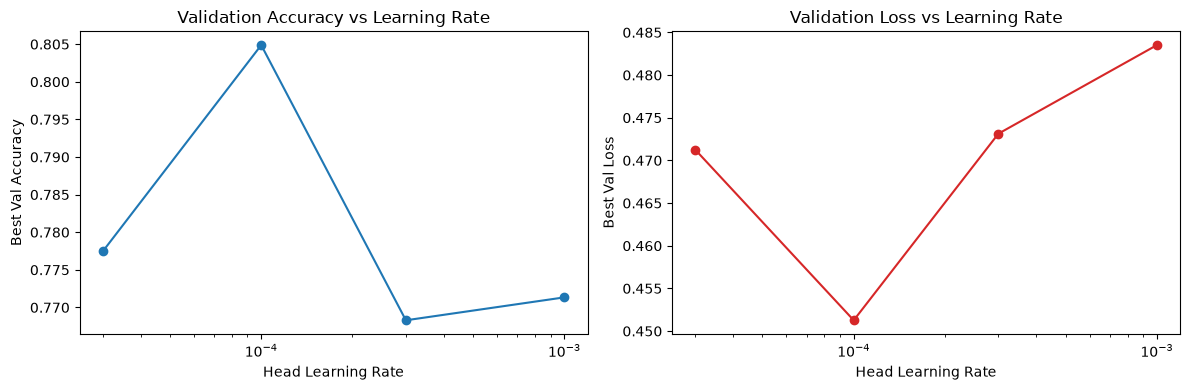

Best learning rate: head_lr=1e-04, backbone_lr=1e-05 (val_acc=0.8049)


In [12]:
# --- Comparison plots + automatic selection ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(stage1_df["head_lr"], stage1_df["best_val_accuracy"], marker="o")
axes[0].set_xscale("log"); axes[0].set_xlabel("Head Learning Rate"); axes[0].set_ylabel("Best Val Accuracy")
axes[0].set_title("Validation Accuracy vs Learning Rate")

axes[1].plot(stage1_df["head_lr"], stage1_df["best_val_loss"], marker="o", color="tab:red")
axes[1].set_xscale("log"); axes[1].set_xlabel("Head Learning Rate"); axes[1].set_ylabel("Best Val Loss")
axes[1].set_title("Validation Loss vs Learning Rate")
plt.tight_layout(); plt.show()

best_lr_row = stage1_df.loc[stage1_df["best_val_accuracy"].idxmax()]
BEST_HEAD_LR = best_lr_row["head_lr"]
BEST_BACKBONE_LR = best_lr_row["backbone_lr"]
print(f"Best learning rate: head_lr={BEST_HEAD_LR:.0e}, backbone_lr={BEST_BACKBONE_LR:.0e} "
      f"(val_acc={best_lr_row['best_val_accuracy']:.4f})")

all_results.extend(stage1_results)


## Stage 2 — Weight Decay Optimization

The best learning rate from Stage 1 is frozen. Only weight decay is varied.


In [14]:
import pickle

with open("variables.pkl", "wb") as f:
    pickle.dump({
        "BEST_HEAD_LR": BEST_HEAD_LR,
        "BEST_BACKBONE_LR": BEST_BACKBONE_LR,
    }, f)

In [ ]:
with open("variables.pkl", "rb") as f:
    data = pickle.load(f)

BEST_HEAD_LR = data["BEST_HEAD_LR"]
BEST_BACKBONE_LR = data["BEST_BACKBONE_LR"]

In [13]:
WD_GRID = [1e-5, 1e-4, 1e-3, 1e-2]

stage2_results = []
stage2_histories = {}
for wd in WD_GRID:
    name = f"stage2_wd_{wd:.0e}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=wd, scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
    )
    stage2_histories[name] = hist
    stage2_results.append(row)
    plot_curves(hist, f"Stage 2 — WD={wd:.0e}")

stage2_df = pd.DataFrame(stage2_results)
stage2_df



Experiment: stage2_wd_1e-05
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(stage2_df["weight_decay"], stage2_df["best_val_accuracy"], marker="o")
axes[0].set_xscale("log"); axes[0].set_xlabel("Weight Decay"); axes[0].set_ylabel("Best Val Accuracy")
axes[0].set_title("Validation Accuracy vs Weight Decay")

axes[1].plot(stage2_df["weight_decay"], stage2_df["best_val_loss"], marker="o", color="tab:red")
axes[1].set_xscale("log"); axes[1].set_xlabel("Weight Decay"); axes[1].set_ylabel("Best Val Loss")
axes[1].set_title("Validation Loss vs Weight Decay")
plt.tight_layout(); plt.show()

best_wd_row = stage2_df.loc[stage2_df["best_val_accuracy"].idxmax()]
BEST_WEIGHT_DECAY = best_wd_row["weight_decay"]
print(f"Best weight decay: {BEST_WEIGHT_DECAY:.0e} (val_acc={best_wd_row['best_val_accuracy']:.4f})")

all_results.extend(stage2_results)


## Stage 3 — Scheduler Optimization

Best learning rate and weight decay are frozen. Compares `ReduceLROnPlateau`, `CosineAnnealingLR`,
and `OneCycleLR`.


In [ ]:
SCHEDULERS = ["plateau", "cosine", "onecycle"]

stage3_results = []
stage3_histories = {}
for sched_name in SCHEDULERS:
    name = f"stage3_sched_{sched_name}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=BEST_WEIGHT_DECAY, scheduler_name=sched_name,
        train_loader=train_loader, val_loader=val_loader,
    )
    stage3_histories[name] = hist
    stage3_results.append(row)
    plot_curves(hist, f"Stage 3 — Scheduler={sched_name}")

stage3_df = pd.DataFrame(stage3_results)
stage3_df


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(stage3_df["scheduler"], stage3_df["best_val_accuracy"], color="tab:blue")
ax.set_ylabel("Best Val Accuracy"); ax.set_title("Validation Accuracy by Scheduler")
plt.tight_layout(); plt.show()

best_sched_row = stage3_df.loc[stage3_df["best_val_accuracy"].idxmax()]
BEST_SCHEDULER = best_sched_row["scheduler"]
print(f"Best scheduler: {BEST_SCHEDULER} (val_acc={best_sched_row['best_val_accuracy']:.4f})")

all_results.extend(stage3_results)


## Results so far

Combined table for Stages 0-3, exported to CSV. The `BEST_HEAD_LR`, `BEST_BACKBONE_LR`,
`BEST_WEIGHT_DECAY`, and `BEST_SCHEDULER` variables above carry forward into Stage 4
(augmentation), Stage 5 (class imbalance / loss function), Stage 6 (optimizer), and the final
combined training run — each of which follows the same `train_experiment(...)` pattern used here
and can be appended below once you're ready to continue.


In [ ]:
results_df = pd.DataFrame(all_results)
results_csv_path = os.path.join(RESULTS_DIR, "stage0_to_3_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved combined results to {results_csv_path}")
results_df
